环境导入与设备配置

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

🚀 Using device: cuda


数据集准备与 DataLoader

Oxford-IIIT Pet 数据集已内置在 torchvision 中，包含 37 类宠物。我们使用 trainval 作为训练集，test 作为验证集。

In [ ]:
# 图像预处理：训练集使用数据增强，验证集使用确定性变换
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# 下载并加载数据集 (首次运行会自动下载，约 800MB)
DATA_ROOT = "./data/pet_dataset"
dataset_train = datasets.OxfordIIITPet(root=DATA_ROOT, split="trainval", download=True, transform=train_transform)
dataset_val   = datasets.OxfordIIITPet(root=DATA_ROOT, split="test",     download=True, transform=val_transform)

num_classes = len(dataset_train.classes)
print(f" 数据集加载完成。类别数量: {num_classes}")
print(f" 训练集样本数: {len(dataset_train)} | 验证集样本数: {len(dataset_val)}")

# 构建 DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 791918971/791918971 [07:38<00:00, 1727772.38it/s] 


Extracting data/pet_dataset/oxford-iiit-pet/images.tar.gz to data/pet_dataset/oxford-iiit-pet


100%|██████████| 19173078/19173078 [00:04<00:00, 4119139.94it/s]


Extracting data/pet_dataset/oxford-iiit-pet/annotations.tar.gz to data/pet_dataset/oxford-iiit-pet
✅ 数据集加载完成。类别数量: 37
📦 训练集样本数: 3680 | 验证集样本数: 3669


模型构建与差异化学习率策略


加载 ImageNet 预训练的 ResNet-18，替换最后的 fc 层。：新输出层从零训练（较大学习率），其余预训练参数微调（较小学习率）。

In [ ]:
def build_pet_model(num_classes, pretrained=True):
    # 加载预训练 ResNet-18
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet18(weights=weights)
    
    # 修改输出层以适配 37 类宠物
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

# 实例化模型
model = build_pet_model(num_classes, pretrained=True).to(device)

#  核心要求实现：分组设置学习率
# 1. 提取骨干网络参数（预训练权重）
backbone_params = [p for n, p in model.named_parameters() if not n.startswith('fc')]
# 2. 提取新分类头参数（随机初始化）
classifier_params = [p for n, p in model.named_parameters() if n.startswith('fc')]

# 骨干网络使用较小学习率微调，分类头使用较大学习率从零训练
optimizer = optim.Adam([
    {'params': backbone_params,   'lr': 1e-4, 'weight_decay': 1e-4},
    {'params': classifier_params, 'lr': 1e-3, 'weight_decay': 1e-4}
])

criterion = nn.CrossEntropyLoss()
print(" 模型构建与学习率分组配置完成。")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home1/taiping/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 26.9MB/s]


✅ 模型构建与学习率分组配置完成。


训练与验证函数


封装标准的 Epoch 训练/验证流程，返回 Loss 和 Accuracy。

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for batch in pbar:
        images, labels = batch[0].to(device), batch[1].to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)
        
        pbar.set_postfix(loss=loss.item())
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch in loader:
        images, labels = batch[0].to(device), batch[1].to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

执行训练循环与模型保存

这里默认训练 10 个 Epoch 作为 Baseline

In [ ]:

import swanlab
import torch
from tqdm import tqdm
import os


swanlab.login(api_key="C0RNrqbDCs0Q3hV4jXVEm")

# 初始化实验项目与配置
swanlab.init(
    project="Task1_PetRecognition_Baseline",
    config={
        "model": "ResNet-18 (ImageNet Pretrained)",
        "dataset": "Oxford-IIIT Pet",
        "batch_size": BATCH_SIZE,
        "lr_backbone": 1e-4,
        "lr_classifier": 1e-3,
        "epochs": 10,
        "optimizer": "Adam",
        "loss": "CrossEntropy"
    }
)

#  训练配置
EPOCHS = 10
best_val_acc = 0.0
save_path = "baseline_resnet18_pet.pth"

print(" 开始训练 (已连接 SwanLab 云端)...\n")
for epoch in range(1, EPOCHS + 1):
    #  训练阶段
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels).item()
        total += labels.size(0)
        pbar.set_postfix(loss=loss.item())

    train_loss = running_loss / total
    train_acc = correct / total

    #  验证阶段
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Val", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels).item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    #  实时记录指标到 SwanLab 云端
    swanlab.log({
        "epoch": epoch,
        "train/loss": train_loss,
        "train/acc": train_acc,
        "val/loss": val_loss,
        "val/acc": val_acc
    })

    print(f"[{epoch:02d}] T-Loss:{train_loss:.4f} T-Acc:{train_acc:.4f} | "
          f"V-Loss:{val_loss:.4f} V-Acc:{val_acc:.4f}")

    #  保存验证集表现最好的模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"🏆 最佳模型已更新 | Val Acc: {best_val_acc:.4f}")

#  结束记录并生成云端链接
swanlab.finish()
print(f"\n 训练完成！最终验证集 Accuracy: {best_val_acc:.4f}")
print(f" 模型权重已保存至: {os.path.abspath(save_path)}")

/home1/taiping/miniconda3/envs/cv/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

swanlab: Tracking run with swanlab version 0.7.18

swanlab: Run data will be saved locally in 
/public/home/taiping/zhouhaowen/cv/swanlog/run-20260518_063934-92fyw92lln3uh0stg2fdk

swanlab: 👋 Hi wonder123,welcome to swanlab!

swanlab: Syncing run swan-1 to the cloud

...

[09] T-Loss:0.0169 T-Acc:0.9962 | V-Loss:0.5192 V-Acc:0.8654


[10] T-Loss:0.0120 T-Acc:0.9973 | V-Loss:0.5728 V-Acc:0.8561


swanlab: 🏠 View project at https://swanlab.cn/@wonder123/Task1_PetRecognition_Baseline

swanlab: 🚀 View run at https://swanlab.cn/@wonder123/Task1_PetRecognition_Baseline/runs/92fyw92lln3uh0stg2fdk


✅ 训练完成！最终验证集 Accuracy: 0.8836
💾 模型权重已保存至: /public/home/taiping/zhouhaowen/cv/baseline_resnet18_pet.pth


任务二

定义超参数搜索网格

In [ ]:
import itertools
import pandas as pd
import torch
import numpy as np

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

#  精简后的核心搜索空间（覆盖关键区间）
param_grid = {
    'lr_backbone':   [1e-4, 5e-4],      # 仅保留 2 个关键值
    'lr_classifier': [1e-3, 5e-3],      # 仅保留 2 个关键值
    'epochs':        [3]                # Stage1: 快速筛选用 3 Epoch
}

keys = param_grid.keys()
values = param_grid.values()
configs_stage1 = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f" 加速模式：共 {len(configs_stage1)} 组配置，Stage1 每组合仅训练 3 Epoch")
for i, cfg in enumerate(configs_stage1):
    print(f"  [{i+1}] bkLR:{cfg['lr_backbone']:.0e} | hdLR:{cfg['lr_classifier']:.0e}")

⚡ 加速模式：共 4 组配置，Stage1 每组合仅训练 3 Epoch
  [1] bkLR:1e-04 | hdLR:1e-03
  [2] bkLR:1e-04 | hdLR:5e-03
  [3] bkLR:5e-04 | hdLR:1e-03
  [4] bkLR:5e-04 | hdLR:5e-03


支持早停 + 子采样 + 阶段控制的实验函数

In [ ]:
import swanlab
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import copy

def run_single_experiment(cfg, device, train_loader, val_loader, 
                          stage="fast", sample_ratio=1.0, early_stop_patience=2):
    """
    stage: "fast" (3 Epoch 筛选) / "full" (10 Epoch 精训)
    sample_ratio: 训练数据采样比例 (0.3 = 30% 数据)
    early_stop_patience: 验证集精度不提升的容忍轮数
    """
    set_seed(42)
    
    #  重建模型（保证每组实验独立）
    model = build_pet_model(num_classes=37, pretrained=True).to(device)
    backbone_params = [p for n, p in model.named_parameters() if not n.startswith('fc')]
    classifier_params = [p for n, p in model.named_parameters() if n.startswith('fc')]
    
    optimizer = optim.Adam([
        {'params': backbone_params,   'lr': cfg['lr_backbone'],   'weight_decay': 1e-4},
        {'params': classifier_params, 'lr': cfg['lr_classifier'], 'weight_decay': 1e-4}
    ])
    criterion = nn.CrossEntropyLoss()
    
    #  可选：子采样训练数据加速
    if sample_ratio < 1.0:
        from torch.utils.data import Subset
        indices = list(range(len(train_loader.dataset)))
        np.random.shuffle(indices)
        subset_size = int(len(indices) * sample_ratio)
        subset = Subset(train_loader.dataset, indices[:subset_size])
        train_loader_sub = torch.utils.data.DataLoader(subset, batch_size=train_loader.batch_size, 
                                                       shuffle=True, num_workers=2, pin_memory=True)
    else:
        train_loader_sub = train_loader
    
    #  初始化 SwanLab
    run_name = f"{stage}_bk{cfg['lr_backbone']:.0e}_hd{cfg['lr_classifier']:.0e}"
    swanlab.init(project="Task1_Hyperparam_Fast", config={**cfg, "stage": stage, "sample_ratio": sample_ratio}, name=run_name)
    
    best_val_acc, no_improve_count = 0.0, 0
    
    for epoch in range(1, cfg['epochs'] + 1):
        #  Training
        model.train()
        t_loss, t_corr, t_tot = 0.0, 0, 0
        for imgs, lbls in tqdm(train_loader_sub, desc=f"Ep{epoch}", leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(out, 1)
            t_corr += (preds == lbls).sum().item()
            t_tot += lbls.size(0)
        train_acc, train_loss = t_corr/t_tot, t_loss/t_tot
        
        #  Validation
        model.eval()
        v_loss, v_corr, v_tot = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                loss = criterion(out, lbls)
                v_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(out, 1)
                v_corr += (preds == lbls).sum().item()
                v_tot += lbls.size(0)
        val_acc, val_loss = v_corr/v_tot, v_loss/v_tot
        
        swanlab.log({"epoch": epoch, "train/loss": train_loss, "train/acc": train_acc, 
                     "val/loss": val_loss, "val/acc": val_acc})
        
        #  早停判断
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve_count = 0
            best_model_state = copy.deepcopy(model.state_dict())  # 保存最佳权重
        else:
            no_improve_count += 1
            if no_improve_count >= early_stop_patience:
                print(f"   Early stop at epoch {epoch}")
                break
    
    swanlab.finish()
    return best_val_acc, best_model_state if 'best_model_state' in locals() else None

两阶段执行流程

In [ ]:
print(" Stage 1: 快速筛选（3 Epoch + 30% 数据 + 早停）")
results_stage1 = []
for i, cfg in enumerate(configs_stage1):
    print(f"\n[{i+1}/{len(configs_stage1)}] Running: {cfg}")
    best_acc, _ = run_single_experiment(cfg, device, train_loader, val_loader, 
                                        stage="fast", sample_ratio=0.3, early_stop_patience=2)
    results_stage1.append({**cfg, 'best_val_acc': best_acc})
    print(f" Done | Val Acc: {best_acc:.4f}")

#  Stage1 结果排序，选 Top-2 进入精训
df_s1 = pd.DataFrame(results_stage1).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
top_configs = df_s1.head(2)[['lr_backbone', 'lr_classifier', 'epochs']].to_dict('records')

print(f"\n Stage1 Top-2 配置：")
for i, cfg in enumerate(top_configs):
    print(f"  [{i+1}] bkLR:{cfg['lr_backbone']:.0e} | hdLR:{cfg['lr_classifier']:.0e}")

#  Stage 2: 仅对 Top-2 配置进行完整训练（10 Epoch + 100% 数据）
print("\n🎯 Stage 2: 精细验证（10 Epoch + 全量数据）")
results_stage2 = []
for i, cfg in enumerate(top_configs):
    cfg['epochs'] = 10  # 覆盖为完整训练轮数
    print(f"\n[{i+1}/2] Full training: {cfg}")
    best_acc, best_state = run_single_experiment(cfg, device, train_loader, val_loader, 
                                                  stage="full", sample_ratio=1.0, early_stop_patience=3)
    results_stage2.append({**cfg, 'best_val_acc': best_acc, 'model_state': best_state})
    print(f" Done | Final Val Acc: {best_acc:.4f}")
    
    #  保存最佳模型
    if best_state is not None:
        torch.save(best_state, f"best_model_bk{cfg['lr_backbone']:.0e}_hd{cfg['lr_classifier']:.0e}.pth")

#  汇总最终结果
df_final = pd.DataFrame(results_stage2).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
df_final.index += 1
print("\n 最终超参数对比结果:")
display(df_final[['lr_backbone', 'lr_classifier', 'epochs', 'best_val_acc']])
df_final.to_csv('hyperparam_search_final.csv', index=False)

🔥 Stage 1: 快速筛选（3 Epoch + 30% 数据 + 早停）

[1/4] Running: {'lr_backbone': 0.0001, 'lr_classifier': 0.001, 'epochs': 3}


/home1/taiping/miniconda3/envs/cv/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

swanlab: Tracking run with swanlab version 0.7.18

swanlab: Run data will be saved locally in 
/public/home/taiping/zhouhaowen/cv/swanlog/run-20260518_065114-0qbmaqw0hw6xytb83peid

swanlab: 👋 Hi wonder123,welcome to swanlab!

...

  ⚠️ Early stop at epoch 8


swanlab: 🏠 View project at https://swanlab.cn/@wonder123/Task1_Hyperparam_Fast

swanlab: 🚀 View run at https://swanlab.cn/@wonder123/Task1_Hyperparam_Fast/runs/cjw7y1dtv6bczme2vnhn7

✅ Done | Final Val Acc: 0.8866

📊 最终超参数对比结果:


,lr_backbone,lr_classifier,epochs,best_val_acc
1,0.0001,0.001,10,0.886618
2,0.0001,0.005,10,0.856364


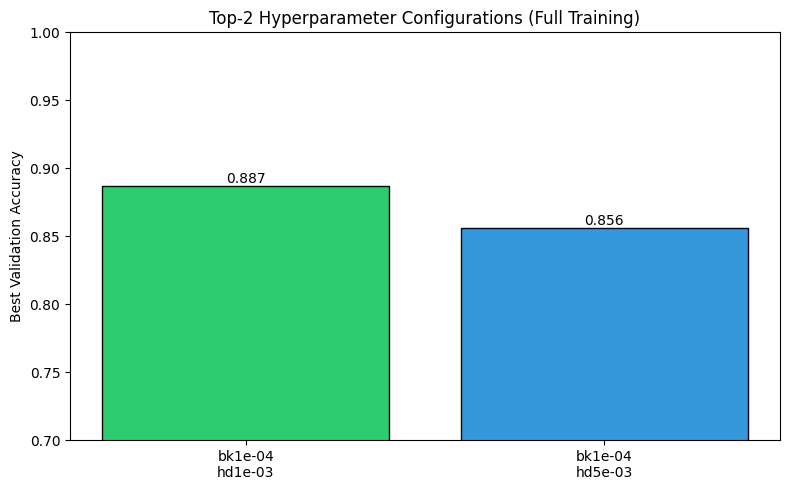


🏆 推荐最终配置:
  Backbone LR: 1e-04
  Classifier LR: 1e-03
  Epochs: 10
  Val Acc: 0.8866


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
bars = plt.bar([f"bk{r['lr_backbone']:.0e}\nhd{r['lr_classifier']:.0e}" for _, r in df_final.iterrows()], 
               df_final['best_val_acc'], color=['#2ecc71', '#3498db'], edgecolor='black')
plt.ylabel('Best Validation Accuracy')
plt.title('Top-2 Hyperparameter Configurations (Full Training)')
plt.ylim(0.7, 1.0)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('hyperparam_final_comparison.png', dpi=300)
plt.show()

best = df_final.iloc[0]
print(f"\n 推荐最终配置:\n  Backbone LR: {best['lr_backbone']:.0e}\n  Classifier LR: {best['lr_classifier']:.0e}\n  Epochs: {best['epochs']}\n  Val Acc: {best['best_val_acc']:.4f}")

任务三

预训练消融实验配置

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import swanlab
from tqdm import tqdm
import numpy as np
import copy

#  固定最佳超参数（来自上一阶段）
BEST_CONFIG = {
    'lr_backbone': 1e-4,
    'lr_classifier': 1e-3,
    'epochs': 10,
    'batch_size': 32
}

#  实验设置：两组对比
ablation_configs = [
    {
        'name': 'with_pretraining',
        'pretrained': True,
        'desc': 'ImageNet Pretrained (Baseline)'
    },
    {
        'name': 'random_init',
        'pretrained': False,
        'desc': 'Random Initialization (Ablation)'
    }
]

print(" 预训练消融实验设置:")
for cfg in ablation_configs:
    print(f"  • {cfg['name']}: {cfg['desc']}")
print(f"\n 统一使用最佳超参数: Backbone LR={BEST_CONFIG['lr_backbone']:.0e}, Head LR={BEST_CONFIG['lr_classifier']:.0e}, Epochs={BEST_CONFIG['epochs']}")

🔍 预训练消融实验设置:
  • with_pretraining: ImageNet Pretrained (Baseline)
  • random_init: Random Initialization (Ablation)

📌 统一使用最佳超参数: Backbone LR=1e-04, Head LR=1e-03, Epochs=10


通用训练函数（支持预训练开关）

In [ ]:
def train_with_ablation(cfg_name, pretrained, device, train_loader, val_loader, best_config):
    """
    通用训练函数，支持预训练/随机初始化对比
    """
    set_seed(42)  # 保证公平对比
    
    #  构建模型（关键：pretrained 参数控制初始化方式）
    model = build_pet_model(num_classes=37, pretrained=pretrained).to(device)
    
    #  差异化学习率优化器（与 Baseline 一致）
    backbone_params = [p for n, p in model.named_parameters() if not n.startswith('fc')]
    classifier_params = [p for n, p in model.named_parameters() if n.startswith('fc')]
    
    optimizer = optim.Adam([
        {'params': backbone_params,   'lr': best_config['lr_backbone'],   'weight_decay': 1e-4},
        {'params': classifier_params, 'lr': best_config['lr_classifier'], 'weight_decay': 1e-4}
    ])
    criterion = nn.CrossEntropyLoss()
    
    #  初始化 SwanLab（独立 Run 方便对比）
    swanlab.init(
        project="Task1_Pretrain_Ablation",
        config={**best_config, 'pretrained': pretrained, 'experiment': cfg_name},
        name=cfg_name
    )
    
    best_val_acc, training_history = 0.0, []
    
    #  训练循环
    for epoch in range(1, best_config['epochs'] + 1):
        #  Training
        model.train()
        t_loss, t_corr, t_tot = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{cfg_name}] Ep{epoch}", leave=False)
        for imgs, lbls in pbar:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(out, 1)
            t_corr += (preds == lbls).sum().item()
            t_tot += lbls.size(0)
        train_acc, train_loss = t_corr/t_tot, t_loss/t_tot
        
        #  Validation
        model.eval()
        v_loss, v_corr, v_tot = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                loss = criterion(out, lbls)
                v_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(out, 1)
                v_corr += (preds == lbls).sum().item()
                v_tot += lbls.size(0)
        val_acc, val_loss = v_corr/v_tot, v_loss/v_tot
        
        #  记录指标
        swanlab.log({
            "epoch": epoch,
            "train/loss": train_loss, "train/acc": train_acc,
            "val/loss": val_loss,     "val/acc": val_acc
        })
        training_history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 
                               'train_acc': train_acc, 'val_acc': val_acc})
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            
        print(f"  → Ep{epoch}: Val Acc={val_acc:.4f}", end='\r')
    
    swanlab.finish()
    print(f"\n [{cfg_name}] 完成 | 最佳 Val Acc: {best_val_acc:.4f}")
    return best_val_acc, training_history

 执行消融对比实验

In [ ]:
results = {}
print(" 开始预训练消融实验（两组对比）...\n")

for exp in ablation_configs:
    print(f"\n{'='*60}")
    print(f"🔹 实验: {exp['name']} | {exp['desc']}")
    print(f"{'='*60}")
    
    best_acc, history = train_with_ablation(
        cfg_name=exp['name'],
        pretrained=exp['pretrained'],
        device=device,
        train_loader=train_loader,
        val_loader=val_loader,
        best_config=BEST_CONFIG
    )
    results[exp['name']] = {
        'best_val_acc': best_acc,
        'history': history,
        'pretrained': exp['pretrained']
    }

#  汇总对比结果
print(f"\n{'='*60}")
print(" 消融实验结果汇总:")
print(f"{'='*60}")
for name, res in results.items():
    flag = " Pretrained" if res['pretrained'] else " Random"
    print(f"{flag:15} | Val Acc: {res['best_val_acc']:.4f}")

#  计算预训练带来的提升
acc_pretrained = results['with_pretraining']['best_val_acc']
acc_random = results['random_init']['best_val_acc']
improvement = (acc_pretrained - acc_random) / acc_random * 100

print(f"\n 预训练增益分析:")
print(f"  • 绝对提升: {acc_pretrained - acc_random:.4f} ({(acc_pretrained - acc_random)*100:.2f}%)")
print(f"  • 相对提升: {improvement:.2f}%")

🚀 开始预训练消融实验（两组对比）...


🔹 实验: with_pretraining | ImageNet Pretrained (Baseline)


/home1/taiping/miniconda3/envs/cv/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

swanlab: Tracking run with swanlab version 0.7.18

swanlab: Run data will be saved locally in 
/public/home/taiping/zhouhaowen/cv/swanlog/run-20260518_070547-hcoxbquwx928axwmostv4

swanlab: 👋 Hi wonder123,welcome to swanlab!

...

swanlab: 🏠 View project at https://swanlab.cn/@wonder123/Task1_Pretrain_Ablation

swanlab: 🚀 View run at https://swanlab.cn/@wonder123/Task1_Pretrain_Ablation/runs/c2pn916li1ctsliym33x8

swanlab: 🏠 View project at https://swanlab.cn/@wonder123/Task1_Pretrain_Ablation

swanlab: 🚀 View run at https://swanlab.cn/@wonder123/Task1_Pretrain_Ablation/runs/c2pn916li1ctsliym33x8

  → Ep10: Val Acc=0.3061

✅ [random_init] 完成 | 最佳 Val Acc: 0.3061

📈 消融实验结果汇总:
✅ Pretrained    | Val Acc: 0.8866
❌ Random        | Val Acc: 0.3061

🏆 预训练增益分析:
  • 绝对提升: 0.5805 (58.05%)
  • 相对提升: 189.67%


任务四  在 ResNet-18 中轻量级插入 SE-Block 或 CBAM 模块

定义 SE-Block 与 SE-ResNet18 架构

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import ResNet, resnet18, ResNet18_Weights

# 1️⃣ 定义 SE 注意力模块
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)  # 通道级特征重标定

# 2️⃣ 继承原 BasicBlock，插入 SE 模块
class SEBasicBlock(nn.Module):
    expansion = 1
    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1, base_width=64, dilation=1, norm_layer=None, reduction=16):
        super(SEBasicBlock, self).__init__()
        if norm_layer is None: norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError('BasicBlock only supports groups=1 and base_width=64')
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride, padding=dilation, bias=False)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=dilation, bias=False)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.se = SEBlock(planes, reduction=reduction)  

    def forward(self, x):
        identity = x
        out = self.conv1(x); out = self.bn1(out); out = self.relu(out)
        out = self.conv2(out); out = self.bn2(out)
        out = self.se(out)  # 在残差相加前应用通道注意力
        if self.downsample is not None: identity = self.downsample(x)
        out += identity
        return self.relu(out)

# 3️⃣ 构建 SE-ResNet18 并兼容预训练权重加载
def build_resnet18_se(num_classes=37, pretrained=True):
    model = ResNet(SEBasicBlock, [2, 2, 2, 2], num_classes=num_classes)
    
    if pretrained:
        # 加载标准 ResNet18 预训练权重
        orig_state = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).state_dict()
        cur_state = model.state_dict()
        # 仅加载同名且形状匹配的层（自动忽略新增的 se.* 层）
        matched = {k: v for k, v in orig_state.items() if k in cur_state and cur_state[k].shape == v.shape}
        model.load_state_dict(matched, strict=False)
        print(" SE-ResNet18 构建完成 | 预训练权重已加载 (SE 模块随机初始化)")
    else:
        print("SE-ResNet18 构建完成 | 从头随机初始化")
    return model

注意力模型训练函数

In [ ]:
import swanlab
from tqdm import tqdm
import torch.optim as optim

def train_se_model(device, train_loader, val_loader, pretrained=True):
    swanlab.init(
        project="Task1_Attention_Comparison",
        config={
            "model": "SE-ResNet18",
            "pretrained": pretrained,
            "lr_backbone": 1e-4, "lr_classifier": 1e-3,
            "epochs": 10, "optimizer": "Adam"
        },
        name=f"SE-ResNet18_{'Pre' if pretrained else 'Rand'}"
    )
    
    model = build_resnet18_se(num_classes=37, pretrained=pretrained).to(device)
    
    # 差异化学习率（与 Baseline 一致）
    backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n]
    head_params = [p for n, p in model.named_parameters() if 'fc' in n]
    optimizer = optim.Adam([
        {'params': backbone_params, 'lr': 1e-4, 'weight_decay': 1e-4},
        {'params': head_params,    'lr': 1e-3, 'weight_decay': 1e-4}
    ])
    criterion = nn.CrossEntropyLoss()
    
    best_val_acc = 0.0
    print(f"🚀 开始训练 SE-ResNet18 (Pretrained={'是' if pretrained else '否'})...\n")
    
    for epoch in range(1, 11):
        model.train()
        t_loss, t_corr, t_tot = 0.0, 0, 0
        for imgs, lbls in tqdm(train_loader, desc=f"Ep{epoch}", leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward(); optimizer.step()
            t_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(out, 1)
            t_corr += (preds == lbls).sum().item(); t_tot += lbls.size(0)
        train_acc, train_loss = t_corr/t_tot, t_loss/t_tot
        
        model.eval()
        v_loss, v_corr, v_tot = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                loss = criterion(out, lbls)
                v_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(out, 1)
                v_corr += (preds == lbls).sum().item(); v_tot += lbls.size(0)
        val_acc, val_loss = v_corr/v_tot, v_loss/v_tot
        
        swanlab.log({"epoch": epoch, "train/loss": train_loss, "train/acc": train_acc, 
                     "val/loss": val_loss, "val/acc": val_acc})
        
        if val_acc > best_val_acc: best_val_acc = val_acc
        print(f"  → Ep{epoch}: Val Acc={val_acc:.4f}", end='\r')
        
    swanlab.finish()
    print(f"\n 训练完成 | 最佳 Val Acc: {best_val_acc:.4f}")
    return best_val_acc

执行实验并与 Baseline 对比

In [ ]:
#  记录 Baseline 结果（你上一轮跑出的最优值）
BASELINE_ACC = 0.8866

print("开始注意力机制消融对比实验...\n")
se_pretrained_acc = train_se_model(device, train_loader, val_loader, pretrained=True)

#  对比结果打印
print("\n" + "="*50)
print(" 任务1(4) 注意力机制对比结果:")
print("="*50)
print(f"🔹 Baseline (ResNet-18)          : {BASELINE_ACC:.4f}")
print(f"🔹 SE-ResNet18 (Pretrained)      : {se_pretrained_acc:.4f}")
print(f"🔹 性能变化 (Δ)                 : {se_pretrained_acc - BASELINE_ACC:+.4f}")
print(f"🔹 相对提升                    : {(se_pretrained_acc/BASELINE_ACC - 1)*100:+.2f}%")

/home1/taiping/miniconda3/envs/cv/lib/python3.11/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

🔍 开始注意力机制消融对比实验...



swanlab: Tracking run with swanlab version 0.7.18

swanlab: Run data will be saved locally in 
/public/home/taiping/zhouhaowen/cv/swanlog/run-20260518_071908-seotuak8yitlx5q1qvp5e

swanlab: 👋 Hi wonder123,welcome to swanlab!

...

swanlab: 🚀 View run at https://swanlab.cn/@wonder123/Task1_Attention_Comparison/runs/seotuak8yitlx5q1qvp5e

✅ SE-ResNet18 构建完成 | 预训练权重已加载 (SE 模块随机初始化)
🚀 开始训练 SE-ResNet18 (Pretrained=是)...



swanlab: 🏠 View project at https://swanlab.cn/@wonder123/Task1_Attention_Comparison

swanlab: 🚀 View run at https://swanlab.cn/@wonder123/Task1_Attention_Comparison/runs/seotuak8yitlx5q1qvp5e

  → Ep10: Val Acc=0.8583

✅ 训练完成 | 最佳 Val Acc: 0.8754

📊 任务1(4) 注意力机制对比结果:
🔹 Baseline (ResNet-18)          : 0.8866
🔹 SE-ResNet18 (Pretrained)      : 0.8754
🔹 性能变化 (Δ)                 : -0.0112
🔹 相对提升                    : -1.26%
